<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 75 · Hypothesis Testing &amp; Inference</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Significance, p-values &amp; Errors 🎯</div>
  <div style="font-size:15px;color:#eef2ff;max-width:740px;line-height:1.6">What does a p-value actually promise, and what can go wrong? We pin down significance as a false-alarm budget, meet the two error types and statistical power, expose two classic traps, and apply it to a battery-life test that is barely significant and weakly powered.</div>
  <div style="margin-top:16px;font-size:13px;color:#c7d2fe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
# statsmodels = the R/SAS-style stats library (pre-installed on Colab): it computes the
# standard errors, test statistics, intervals, and post-hoc comparisons, so we write less by hand.
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep, proportion_confint
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.weightstats import DescrStatsW, CompareMeans
from scipy.stats.contingency import association   # Cramer's V in one call
IND="#4f46e5"; DEEP="#4338ca"; LIGHT="#818cf8"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"; AMBER="#d97706"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
rng = np.random.default_rng(75)

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4338ca;letter-spacing:1px">DEMO 1 · WHAT 'SIGNIFICANT' MEANS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Alpha is the false-alarm rate</div>
<div style="color:#4a5578;margin-top:6px">Choosing significance level alpha = 0.05 is a promise: if H0 is true, we will wrongly reject it only 5% of the time. We can verify it, run thousands of tests where H0 is TRUE and count how often we 'find' an effect that is not there.</div>
</div>

H0 is TRUE in every trial. Rejections at alpha=0.05: 0.050 (should be ~0.05)


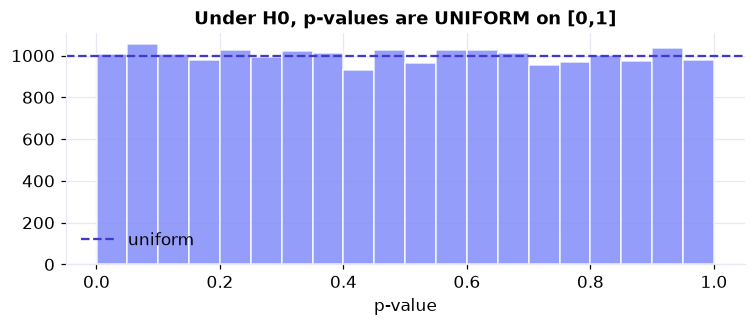

In [2]:
alpha=0.05; trials=20000
pvals=np.array([stats.ttest_1samp(rng.normal(0,1,40), 0).pvalue for _ in range(trials)])
print(f"H0 is TRUE in every trial. Rejections at alpha={alpha}: {np.mean(pvals<alpha):.3f} (should be ~0.05)")
fig,ax=plt.subplots(figsize=(7,3.1))
ax.hist(pvals,bins=20,color=LIGHT,alpha=0.85,edgecolor="white")
ax.axhline(trials/20,color=DEEP,ls="--",lw=1.5,label="uniform")
ax.set_title("Under H0, p-values are UNIFORM on [0,1]"); ax.set_xlabel("p-value"); ax.legend()
plt.tight_layout(); plt.show()

When H0 is true the p-value is uniform, every value is equally likely, so exactly 5% land below 0.05 purely by chance. That 5% is the <strong>Type I error rate</strong> you sign up for. Significance is a controlled false-alarm budget, not a guarantee of truth.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4338ca;letter-spacing:1px">DEMO 2 · THE TWO ERRORS & POWER</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Type I, Type II, and the chance of catching a real effect</div>
<div style="color:#4a5578;margin-top:6px">A test can be wrong two ways: reject a true H0 (Type I, rate alpha) or miss a real effect (Type II, rate beta). POWER = 1 - beta is the probability of detecting an effect that truly exists. Power grows with sample size and with effect size.</div>
</div>

In [3]:
def power_sim(true_mean, n, alpha=0.05, B=4000):
    return np.mean([stats.ttest_1samp(rng.normal(true_mean,1,n),0).pvalue<alpha for _ in range(B)])
print("Power to detect a true mean of 0.5 (sd 1):")
for n in [10,20,40,80,160]:
    print(f"  n={n:>3}: power = {power_sim(0.5,n):.2f}")
print("\nPower vs effect size (n=40):")
for eff in [0.2,0.35,0.5,0.8]:
    print(f"  effect d={eff}: power = {power_sim(eff,40):.2f}")

Power to detect a true mean of 0.5 (sd 1):


  n= 10: power = 0.30
  n= 20: power = 0.57
  n= 40: power = 0.86
  n= 80: power = 0.99


  n=160: power = 1.00

Power vs effect size (n=40):
  effect d=0.2: power = 0.24


  effect d=0.35: power = 0.58
  effect d=0.5: power = 0.86


  effect d=0.8: power = 1.00


Bigger samples and bigger effects both raise power. A small study can easily <em>miss</em> a real effect, that is a Type II error, and "we found no significant difference" from an underpowered test means little. Designing for adequate power (often 80%) is as important as controlling alpha.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4338ca;letter-spacing:1px">DEMO 3 · TWO CLASSIC TRAPS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Multiple comparisons and significance vs importance</div>
<div style="color:#4a5578;margin-top:6px">Run 20 tests on pure noise and about one comes out 'significant' by luck (multiple comparisons). And with a huge sample, a trivially small effect becomes 'significant', a low p-value does not mean a large or important effect.</div>
</div>

In [4]:
# Trap 1: multiple comparisons on pure noise
sig=sum(stats.ttest_ind(rng.normal(0,1,50),rng.normal(0,1,50)).pvalue<0.05 for _ in range(20))
print(f"20 tests, all H0 true -> {sig} came out significant (expected ~1) -> false positives multiply")
# Trap 2: significance != importance
big=rng.normal(0.02,1,100000)   # a tiny true effect of 0.02
p=stats.ttest_1samp(big,0).pvalue
print(f"\nn=100000, true effect only 0.02: p={p:.2e} (significant!) but effect size d={big.mean()/big.std():.3f} (negligible)")
print("Lesson: always report an EFFECT SIZE and a confidence interval alongside the p-value.")

20 tests, all H0 true -> 2 came out significant (expected ~1) -> false positives multiply

n=100000, true effect only 0.02: p=3.19e-10 (significant!) but effect size d=0.020 (negligible)
Lesson: always report an EFFECT SIZE and a confidence interval alongside the p-value.


Two of the most common ways p-values mislead: testing many things until one "wins" (fix with corrections like Bonferroni or false-discovery-rate control), and confusing a tiny p with a big effect (fix by reporting effect size and a confidence interval). Statistical significance is not practical importance.

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">REAL-WORLD EXAMPLE · BATTERY LIFE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A barely-significant result with weak power</div>
<div style="color:#4a5578;margin-top:6px"></div>
</div>

A battery is spec&#8217;d at <strong>10.0 hours</strong>. An engineer tests 50 units (`significance-p-values-and-errors--battery_life.xlsx`) and suspects they run short. We test H0: mu = 10 against H1: mu &lt; 10, then ask the harder question: how often would a test this size even catch a real shortfall?

In [5]:
try:    bat = pd.read_excel("../../data/significance-p-values-and-errors--battery_life.xlsx", sheet_name="Batteries")
except FileNotFoundError: bat = pd.read_excel(BASE+"significance-p-values-and-errors--battery_life.xlsx", sheet_name="Batteries")
# EXPLORE FIRST: size, missing, and a summary by model
print("shape:", bat.shape, "| missing:", bat.isna().sum().sum())
print(bat.groupby("model").life_hours.agg(["size","mean","std"]).round(3))
x=bat["life_hours"]; mu0=10.0; n=len(x)
res=stats.ttest_1samp(x,mu0); p_one=res.pvalue/2
d=(x.mean()-mu0)/x.std(ddof=1)
print(f"n={n}, mean={x.mean():.3f} h, sd={x.std(ddof=1):.3f}")
print(f"t={res.statistic:.2f}, one-sided p={p_one:.4f}  -> {'REJECT' if p_one<0.05 else 'fail to reject'} H0 at 5%")
print(f"effect size Cohen\u2019s d = {d:.2f} (small)")

shape: (50, 5) | missing: 0
       size   mean    std
model                    
A100     20  9.612  0.759
A200     30  9.950  0.764
n=50, mean=9.815 h, sd=0.773
t=-1.70, one-sided p=0.0481  -> REJECT H0 at 5%
effect size Cohen’s d = -0.24 (small)


In [6]:
# Power via statsmodels (no hand-rolled noncentral t): how often would we catch this shortfall?
from statsmodels.stats.power import TTestPower
analysis = TTestPower()
power = analysis.power(effect_size=d, nobs=n, alpha=0.05, alternative="smaller")
print(f"power at the observed effect (n={n}, alpha=.05, one-sided) = {power:.2f}")
print("how many units for more power at this effect size:")
for nn in [50,100,150,200,300]:
    pw = analysis.power(effect_size=d, nobs=nn, alpha=0.05, alternative="smaller")
    print(f"  n={nn:>3}: power = {pw:.2f}")
print("To reliably catch a shortfall this small, the engineer needs a far larger sample.")

power at the observed effect (n=50, alpha=.05, one-sided) = 0.51
how many units for more power at this effect size:
  n= 50: power = 0.51
  n=100: power = 0.77
  n=150: power = 0.90
  n=200: power = 0.96
  n=300: power = 0.99
To reliably catch a shortfall this small, the engineer needs a far larger sample.


The result is <strong>just barely significant</strong> (one-sided p &#8776; 0.048): we reject the 10-hour claim, but only by a hair. And the power is only about <strong>0.51</strong>, this test would miss a real shortfall of this size nearly half the time. A borderline p with low power is fragile evidence; the honest move is to report the effect size (d &#8776; &#8722;0.24), the confidence interval, and to recommend a larger confirmatory sample rather than declaring victory.

<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ Significance, errors &amp; power</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">Alpha is the Type I (false-alarm) rate you accept; beta is the Type II (miss) rate, and power = 1 - beta is the chance of catching a real effect. p-values are uniform under H0, multiply under many comparisons, and shrink with sample size regardless of importance, so always pair them with an effect size and a CI. On real battery data the shortfall is barely significant (p &#8776; 0.048) with weak power (&#8776; 0.51), fragile evidence that calls for a bigger sample. Next: the z-tests that put this logic to work on means and proportions.</div></div>

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>